# (A) Identification of Candidate Datasets


---



## Candidate 1

**Dataset Name and Source:**
- *Name:* Spotify Tracks Dataset
- *Source:* Kaggle (https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data)

**Course Topic Alignment:**
- Clustering

**Potential Beyond-Course Techniques:**
- Pattern Mining

**Datasize and Structure:**
- *Num. Of Entries in Dataset:* 89741
- *Structure:* CSV
- *File Size:* 20.12 MB

**Data Types:**
- *Numeric:* Track IDs, Popularity, Duration, Danceability, # Energy
- *String:* Track Name, Artist, Album
- *Bool:* Explicit

**Target Variables:**
- Linking Genre to Danceability
- Does the explicit-ness of a song impact popularity?

**Licensing or Usage Constraints:**
- Open Data Commons Open Database License (ODbL) v1.0: https://opendatacommons.org/licenses/odbl/1-0/


---



## Candidate 2
**Dataset Name and Source:**
- *Name:* IMDb Non-Commercial Datasets
- *Source:* IMDb (https://developer.imdb.com/non-commercial-datasets/)

**Course Topic Alignment:**
- Frequent itemsets
- PageRank

**Potential Beyond-Course Techniques:**
- Link Prediction

**Datasize and Structure:**
- *Num. of Entries in Dataset:* Varies by file
- *Structure:* TSV
- *File Size (All sizes are of compressed dataset):*
  - name.basics.tsv.gz:   291 MB
  - title.akas.tsv.gz:    466 MB
  - title.basics.tsv.gz:  212 MB
  - title.crew.tsv.gz:    78 MB
  - title.episode.tsv.gz: 51 MB
  - title.ratings.tsv.gz: 8 MB

**Data Types:**
- *Numeric:* IDs for Seasons, Titles, Episodes; Runtime; Birth Year; Death Year; Number of Votes
- *Strings:* Genres, Language, Title, Job, Characters, Region
- *Bool:* Is Adult?, Is Original Title?

**Target Variables:**
- Do directors who work with succcessful directors go on to have their own successful careers?
- Trends in actor popularity over the course of their career

**Licensing or Usage Constraints:**
- Non-Commercial Licensing: https://help.imdb.com/article/imdb/general-information/can-i-use-imdb-data-in-my-software/G5JTRESSHJBBHTGX?pf_rd_m=A2FGELUUNOQJNL&pf_rd_p=1ed1aea6-d2ad-4705-95fd-ba13f1b5014f&pf_rd_r=XRE3QWF2G5YWTD2SGT0V&pf_rd_s=center-1&pf_rd_t=60601&pf_rd_i=interfaces&ref_=fea_mn_lk1#


---



## Candidate 3
**Dataset Name and Source:**
- *Name:* FEC Contributor and Operating Expenses Data
- *Source:* Federal Elections Committee (https://www.fec.gov/data/browse-data/?tab=bulk-data)

**Course Topic Alignment:**
- Clustering
- Decision Trees

**Potential Beyond-Course Techniques:**
- Link Prediction

**Datasize and Structure:**
- *Num. of Entries in Dataset:* Varies by file
- *Structure:* Pipe-Separated Values (PSV)
- *File Size (All sizes are of compressed dataset):*
  - 2025-2026 Individual Contribution Data (indiv26.zip): 856 MB
  - 2024-2026 Operating Expenditures (oppexp26.zip) 17 MB

**Data Types:**
- *Numeric:* Transaction Amount/ID, Transaction Date
- *String:* State, City, Name, Purpose, Memo Text, Memo Code


**Target Variables:**
- None

**Licensing or Usage Constraints:**
- Public Domain
- Usage Constraints
  - Cannot be used for soliciting contributions
  - Cannot be used for commercial purposes
  - Cannot sell or redistribute contributor information for marketing purposes

# (B) Comparative Analysis of Datasets

In [1]:
# Environment Setup
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
import os

warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

DRIVE_MOUNTED = False
DRIVE_DIR = '/content/drive'
PROJECT_DIR = '/MyDrive/CSCE_676/Project'
DATASET_DIRS = ['/SpotifyTracksDataset', '/IMDbDatasets', '/FECDatasets']

In [17]:
def data_quality_report(df, sample_rows=5):
    print("=== BASIC INFO ===")
    print(f"Shape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)

    print("\n=== MISSING VALUES ===")
    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)
    missing_df = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    })
    print(missing_df[missing_df["missing_count"] > 0])

    print("\n=== DUPLICATES ===")
    dup_count = df.duplicated().sum()
    print(f"Duplicate rows: {dup_count}")

    print("\n=== SUMMARY STATISTICS (NUMERIC) ===")
    numeric_df = df.select_dtypes(include=[np.number])
    if not numeric_df.empty:
        print(numeric_df.describe().T)
    else:
        print("No numeric columns to summarize.")

    print("\n=== SUMMARY STATISTICS (OBJECT) ===")
    object_df = df.select_dtypes(include=['object'])
    if not object_df.empty:
        print(object_df.describe().T)
    else:
        print("No object columns to summarize.")

    print("\n=== UNIQUE VALUES (CATEGORICAL) ===")
    cat_cols = df.select_dtypes(include=['object']).columns
    if not cat_cols.empty:
        for col in cat_cols:
            print(f"{col}: {df[col].nunique()} unique values")
    else:
        print("No categorical columns to summarize unique values.")

    print("\n=== SAMPLE ROWS ===")
    display(df.sample(sample_rows))

    print("\n=== POTENTIAL OUTLIERS (NUMERIC) ===")
    if not numeric_df.empty:
        for col in numeric_df.columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = ((df[col] < lower) | (df[col] > upper)).sum()
            print(f"{col}: {outliers} potential outliers")
    else:
        print("No numeric columns to check for outliers.")

if not DRIVE_MOUNTED:
  drive.mount(DRIVE_DIR)
  DRIVE_MOUNTED = True

for dataset_dir in DATASET_DIRS:
  print("Dataset Directory:", dataset_dir)
  print(f"  Files: {os.listdir(DRIVE_DIR + PROJECT_DIR + dataset_dir)}")

Dataset Directory: /SpotifyTracksDataset
  Files: ['track_data.zip']
Dataset Directory: /IMDbDatasets
  Files: ['title.ratings.tsv.gz', 'title.episode.tsv.gz', 'title.crew.tsv.gz', 'title.basics.tsv.gz', 'name.basics.tsv.gz', 'title.akas.tsv.gz']
Dataset Directory: /FECDatasets
  Files: ['indiv26.zip', 'indiv_header_file.csv', 'oppexp26.zip', 'oppexp_header_file.csv']


## Candidate 1: Spotify Tracks Dataset


In [3]:
spotify_data_zip_path = DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[0] + '/track_data.zip'

spotify_df = pd.read_csv(spotify_data_zip_path, compression='zip')

data_quality_report(spotify_df)

=== BASIC INFO ===
Shape: (114000, 21)

Data Types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== MISSING VALUES ===
            missing_count  missing_pct
artists                 1          0.0
album_name              1          0.0
track_name              1          0.0

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
                     count           mean            std     min  \
Unnamed: 0        1140

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
70533,70533,1u25V63Qw64EkVh90Jyrmh,Faye Wong,王菲97,人間,47,285266,False,0.603,0.29800,...,-11.761,0,0.0278,0.7430,0.000009,0.267,0.2980,130.041,4,mandopop
101808,101808,4VdLOyYe6ZEyLx0LbYdyvy,Cameron Sinosa,Querencia,Querencia,59,194648,False,0.170,0.00316,...,-38.615,0,0.0422,0.9910,0.931000,0.111,0.0946,70.964,3,sleep
60338,60338,1luiKI89ae86nncHOZRZJj,Franco Wildlife;Bobby 6ix,North Coast,Bang,23,161854,True,0.631,0.71600,...,-3.505,1,0.4340,0.0285,0.000003,0.127,0.2320,81.432,1,j-dance
85035,85035,2vU6bm5hVF2idVknGzqyPL,The Offspring,Alternative Christmas 2022,Christmas (Baby Please Come Home),0,187355,False,0.437,0.87800,...,-4.687,1,0.0452,0.0112,0.000000,0.126,0.6230,128.043,4,punk-rock
20749,20749,0mhMSxIx2XnXCF7PDLjUGG,Ty Dolla $ign;Lil Wayne;The-Dream,Rap Ice,Love U Better,0,181872,False,0.627,0.56200,...,-6.268,0,0.0364,0.0628,0.000000,0.310,0.3890,95.054,4,dance



=== POTENTIAL OUTLIERS (NUMERIC) ===
Unnamed: 0: 0 potential outliers
popularity: 2 potential outliers
duration_ms: 5617 potential outliers
danceability: 620 potential outliers
energy: 0 potential outliers
key: 0 potential outliers
loudness: 6173 potential outliers
mode: 0 potential outliers
speechiness: 13211 potential outliers
acousticness: 0 potential outliers
instrumentalness: 25246 potential outliers
liveness: 8642 potential outliers
valence: 0 potential outliers
tempo: 617 potential outliers
time_signature: 12157 potential outliers


## Candidate 2: IMDb Non-Commercial Datasets

In [4]:
imdb_basics_data_filepath = DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[1] + '/title.basics.tsv.gz'

imdb_basics_df = pd.read_csv(imdb_basics_data_filepath, compression='gzip', sep="\t")

data_quality_report(imdb_basics_df)

=== BASIC INFO ===
Shape: (12269550, 9)

Data Types:
tconst            object
titleType         object
primaryTitle      object
originalTitle     object
isAdult            int64
startYear         object
endYear           object
runtimeMinutes    object
genres            object
dtype: object

=== MISSING VALUES ===
               missing_count  missing_pct
primaryTitle              25          0.0
originalTitle             25          0.0
genres                   528          0.0

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
              count      mean        std  min  25%  50%  75%     max
isAdult  12269550.0  0.117853  12.993515  0.0  0.0  0.0  0.0  2025.0

=== SUMMARY STATISTICS (OBJECT) ===
                   count    unique           top      freq
tconst          12269550  12269550     tt9916880         1
titleType       12269550        11     tvEpisode   9467727
primaryTitle    12269525   5498018  Episode #1.1     57991
originalTitle   12269525   55

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
12169120,tt9700252,tvEpisode,Episode #1.50,Episode #1.50,0,2016,\N,\N,Drama
11203763,tt7591896,tvEpisode,Episode #1.3,Episode #1.3,0,2015,\N,\N,"Drama,Romance"
4438586,tt16586248,tvEpisode,Episode #1.28,Episode #1.28,0,2021,\N,\N,Drama
9872968,tt4600190,tvEpisode,Episode #1.44,Episode #1.44,0,\N,\N,\N,"Drama,Romance"
301555,tt0315256,movie,Half Man and Half Beast,Bansubanin,0,1975,\N,\N,Horror



=== POTENTIAL OUTLIERS (NUMERIC) ===
isAdult: 400782 potential outliers


## Candidate 3: Federal Elections Individual Contributor and Operating Expenses Data

In [5]:
fec_oppexp_header_filepath = DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[2] + '/oppexp_header_file.csv'
fec_oppexp_data_filepath = DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[2] + '/oppexp26.zip'

fec_oppexp_columns = pd.read_csv(fec_oppexp_header_filepath, header=None).iloc[0].tolist()
fec_oppexp_df = pd.read_csv(fec_oppexp_data_filepath, compression='zip', sep="|", names=fec_oppexp_columns)
fec_oppexp_df.head()

data_quality_report(fec_oppexp_df)

=== BASIC INFO ===
Shape: (638445, 25)

Data Types:
CMTE_ID              object
AMNDT_IND             int64
RPT_YR               object
RPT_TP                int64
IMAGE_NUM            object
LINE_NUM             object
FORM_TP_CD           object
SCHED_TP_CD          object
NAME                 object
CITY                 object
STATE                object
ZIP_CODE             object
TRANSACTION_DT      float64
TRANSACTION_AMT      object
TRANSACTION_PGI      object
PURPOSE              object
CATEGORY             object
CATEGORY_DESC        object
MEMO_CD              object
MEMO_TEXT            object
ENTITY_TP             int64
SUB_ID                int64
FILE_NUM             object
TRAN_ID              object
BACK_REF_TRAN_ID    float64
dtype: object

=== MISSING VALUES ===
                  missing_count  missing_pct
SCHED_TP_CD                   6         0.00
NAME                        724         0.11
CITY                       1382         0.22
STATE                      131

,CMTE_ID,AMNDT_IND,RPT_YR,RPT_TP,IMAGE_NUM,LINE_NUM,FORM_TP_CD,SCHED_TP_CD,NAME,CITY,...,PURPOSE,CATEGORY,CATEGORY_DESC,MEMO_CD,MEMO_TEXT,ENTITY_TP,SUB_ID,FILE_NUM,TRAN_ID,BACK_REF_TRAN_ID
C00845016,N,2025,Q2,202507159762900303,17,F3,SB,"THE KAL GROUP, INC.",HILMAR,CA,...,1.0,Administrative/Salary/Overhead Expenses,NaN,NaN,ORG,4071620251208993384,1901666,B-583,NaN,NaN
C00216614,N,2025,M11,202511209792702466,21B,F3X,SB,"RAKOW-STEPPER, JENNIFER","VIENNA, AUSTRIA 10",NaN,...,NaN,NaN,NaN,NaN,IND,4011220261301165508,1925844,21B-30-08614-0000,NaN,NaN
C00855643,N,2025,Q1,202504159755378038,17,F3,SB,NATIONBUILDER,LOS ANGELES,CA,...,1.0,Administrative/Salary/Overhead Expenses,X,MEMO: DEBT SUBVENDOR OF CHASE CARD SERVICES,ORG,4041720251185313506,1886647,B-5433,B-5472,NaN
C00768994,A,2025,Q3,202512229793854560,17,F3,SB,"MARTINEZ, HANOI",MIAMI,FL,...,NaN,NaN,NaN,NaN,IND,4011320261301504264,1929910,BD16D175758FC49C696B,NaN,NaN
C00498667,N,2025,Q1,202504159755578044,17,F3,SB,"BEALL, CHARLES",MORENO VALLEY,CA,...,NaN,NaN,X,*,IND,4041720251185312261,1887296,500484624,500484625,NaN



=== POTENTIAL OUTLIERS (NUMERIC) ===
AMNDT_IND: 1379 potential outliers
RPT_TP: 55167 potential outliers
TRANSACTION_DT: 85219 potential outliers
ENTITY_TP: 324 potential outliers
SUB_ID: 307 potential outliers
BACK_REF_TRAN_ID: 0 potential outliers


## Candidate Dataset Comparison


---


### Supported Data Mining Tasks:
- Spotify Tracks Dataset:
  - Clustering (course) and pattern mining (beyond-course)
- IMDb Non-Commerial Datasets:
  - Clustering (course) and link prediction (beyond-course)
- FEC Contributor and Operating Expenses Data:
  - Decision trees (course) and linke predication (beyond-course)


---


### Data Quality Issues:
- Spotify Tracks Dataset:
  - Small subset of tracks from Spotify's actual catlog; unsure of how meaningful any conclusions would be when applied to a global context.
- IMDb Non-Commerial Datasets:
  - Initial analysis appears to suggest dataset is well-curated / clean.
- FEC Contributor and Operating Expenses Data:
  - Around 50% of entries appeart to be missing a transaction amount.


---


### Algorithmic Feasibility:
- Spotify Tracks Dataset:
  - Small enoutgh dataset to most anything we might set out to implement.
- IMDb Non-Commerial Datasets:
  - Can meaningful conclusions still be determined from a sampled portion of the dataset if full dataset is to cumbersome (especially for graph analysis)?
- FEC Contributor and Operating Expenses Data:
  - Though most algorithm should be feasible to apply to this dataset, there is some underlying concern that drawing meaningful conclusions would require knowledge of the various form types and other government lingo and know-how, especially if incorporating individual contribtions data into analysis


---


### Bias Considerations:

- Spotify Tracks Dataset:
  - Unsure of how tracks were selected to be in the dataset.
- IMDb Non-Commerial Datasets:
  - As with many datasets that contain data related to reviews, this dataset will be prone to polarization and self-selection bias.
- FEC Contributor and Operating Expenses Data:
  - Only contributions over a certain threshold (varies by year) are captured. Would not be able to capture a complete view of contribution patterns.


---


### Ethical Considerations:
- Spotify Tracks Dataset:
  - None
- IMDb Non-Commerial Datasets:
  - None
- FEC Contributor and Operating Expenses Data:
  - Would have to be mindful that my own political biases do not pollute the quality of the analysis.

# (C) Dataset Selection

**Dataset Selected**: IMDb Non-Commercial Datasets

**Reasons:**
- Clean dataset; sizeable for creating meaningful clusters
- Dataset is compresehensive; lots of potential avenues for exploring questions relating to movies, TV, actors, and directors.

**Trade-offs:**
- Minimal natural text component
-

# (D) Exploratory Data Analysis

In [10]:
# For each file in the IMDb dataset directory, create a DataFrame
imdb_dataframes = {}
for filename in os.listdir(DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[1]):
  # Skip the "Also-Known-As" files. Very large and unsure of how to even meaninfully incorporate
  # into data exploration (at least at the moment)
  if filename == "title.akas.tsv.gz":
    continue

  print(f"Parsing file '{DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[1] + '/' + filename};")
  imdb_dataframes[filename.split('.')[0] + "_" + filename.split('.')[1]] = pd.read_csv(DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[1] + '/' + filename, compression='gzip', sep="\t")

Parsing file '/content/drive/MyDrive/CSCE_676/Project/IMDbDatasets/title.ratings.tsv.gz;
Parsing file '/content/drive/MyDrive/CSCE_676/Project/IMDbDatasets/title.episode.tsv.gz;
Parsing file '/content/drive/MyDrive/CSCE_676/Project/IMDbDatasets/title.crew.tsv.gz;
Parsing file '/content/drive/MyDrive/CSCE_676/Project/IMDbDatasets/title.basics.tsv.gz;
Parsing file '/content/drive/MyDrive/CSCE_676/Project/IMDbDatasets/name.basics.tsv.gz;


In [18]:
# Run initial dataset analysis as done previously for other datasets.
for dataset_name, df in imdb_dataframes.items():
  print(f"================================== {dataset_name.upper()} ==================================")
  data_quality_report(df)

================================== TITLE_RATINGS ==================================
=== BASIC INFO ===
Shape: (1632600, 3)

Data Types:
tconst            object
averageRating    float64
numVotes           int64
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
                   count         mean           std  min   25%   50%    75%  \
averageRating  1632600.0     6.968092      1.411700  1.0   6.2   7.2    7.9   
numVotes       1632600.0  1039.801036  18154.640482  5.0  12.0  27.0  103.0   

                     max  
averageRating       10.0  
numVotes       3153488.0  

=== SUMMARY STATISTICS (OBJECT) ===
          count   unique        top freq
tconst  1632600  1632600  tt9916880    1

=== UNIQUE VALUES (CATEGORICAL) ===
tconst: 1632600 unique values

=== SAMPLE ROWS ===


,tconst,averageRating,numVotes
1404284,tt5497762,7.1,81
1309754,tt4047988,7.1,12
1275607,tt37844474,8.7,25
1322302,tt4227392,5.1,176
932627,tt21160410,5.4,49



=== POTENTIAL OUTLIERS (NUMERIC) ===
averageRating: 44706 potential outliers
numVotes: 253678 potential outliers
================================== TITLE_EPISODE ==================================
=== BASIC INFO ===
Shape: (9469748, 4)

Data Types:
tconst           object
parentTconst     object
seasonNumber     object
episodeNumber    object
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
No numeric columns to summarize.

=== SUMMARY STATISTICS (OBJECT) ===
                 count   unique         top     freq
tconst         9469748  9469748   tt9916880        1
parentTconst   9469748   232052  tt12164062    18593
seasonNumber   9469748      332           1  4785086
episodeNumber  9469748    15915          \N  1943524

=== UNIQUE VALUES (CATEGORICAL) ===
tconst: 9469748 unique values
parentTconst: 232052 unique values
seasonNumber: 332 unique values
episode

,tconst,parentTconst,seasonNumber,episodeNumber
2454860,tt1450369,tt0081857,\N,\N
5619531,tt30691907,tt30488501,1,2296
4019592,tt21095148,tt18336136,1,193
8049223,tt6012098,tt4887628,\N,\N
7839942,tt5366780,tt4468682,3,3



=== POTENTIAL OUTLIERS (NUMERIC) ===
No numeric columns to check for outliers.
================================== TITLE_CREW ==================================
=== BASIC INFO ===
Shape: (12272066, 3)

Data Types:
tconst       object
directors    object
writers      object
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
No numeric columns to summarize.

=== SUMMARY STATISTICS (OBJECT) ===
              count    unique        top     freq
tconst     12272066  12272066  tt9916880        1
directors  12272066    996511         \N  5392281
writers    12272066   1480827         \N  5999151

=== UNIQUE VALUES (CATEGORICAL) ===
tconst: 12272066 unique values
directors: 996511 unique values
writers: 1480827 unique values

=== SAMPLE ROWS ===


...


=== POTENTIAL OUTLIERS (NUMERIC) ===
No numeric columns to check for outliers.
================================== TITLE_BASICS ==================================
=== BASIC INFO ===
Shape: (12269550, 9)

Data Types:
tconst            object
titleType         object
primaryTitle      object
originalTitle     object
isAdult            int64
startYear         object
endYear           object
runtimeMinutes    object
genres            object
dtype: object

=== MISSING VALUES ===
               missing_count  missing_pct
primaryTitle              25          0.0
originalTitle             25          0.0
genres                   528          0.0

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
              count      mean        std  min  25%  50%  75%     max
isAdult  12269550.0  0.117853  12.993515  0.0  0.0  0.0  0.0  2025.0

=== SUMMARY STATISTICS (OBJECT) ===
                   count    unique           top      freq
tconst          12269550  12269550     tt99

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
11402157,tt8025826,tvEpisode,Episode #1.51,Episode #1.51,0,2010,\N,50,Romance
2732564,tt13232460,tvEpisode,Episode #2.111,Episode #2.111,0,\N,\N,\N,Talk-Show
4792321,tt18336578,tvEpisode,Episode #1.26,Episode #1.26,0,2021,\N,\N,Drama
6309949,tt2666176,short,La strada dei capelli. Il mestiere che portò E...,La strada dei capelli. Il mestiere che portò E...,0,2006,\N,20,"Documentary,Short"
6821001,tt28451199,tvEpisode,Episode #1.11,Episode #1.11,0,1954,\N,\N,\N



=== POTENTIAL OUTLIERS (NUMERIC) ===
isAdult: 400782 potential outliers
================================== NAME_BASICS ==================================
=== BASIC INFO ===
Shape: (15071111, 6)

Data Types:
nconst               object
primaryName          object
birthYear            object
deathYear            object
primaryProfession    object
knownForTitles       object
dtype: object

=== MISSING VALUES ===
             missing_count  missing_pct
primaryName             11          0.0

=== DUPLICATES ===
Duplicate rows: 0

=== SUMMARY STATISTICS (NUMERIC) ===
No numeric columns to summarize.

=== SUMMARY STATISTICS (OBJECT) ===
                      count    unique        top      freq
nconst             15071111  15071111  nm9993719         1
primaryName        15071100  11500071       Alex       584
birthYear          15071111       562         \N  14405520
deathYear          15071111       509         \N  14816363
primaryProfession  15071111     26004         \N   3017557
knownF

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
8236735,nm18111518,Paul Evans,\N,\N,camera_department,tt33262257
9949022,nm3659282,Marcelo Cetrulo,\N,\N,actor,tt0431321
1388924,nm10507672,Kaitlyn Nicholson,\N,\N,actress,tt7779146
9586494,nm3260228,Nicolette Chieffe,\N,\N,actress,tt1347278
12613837,nm6888197,Joel Morillo,\N,\N,visual_effects,tt4170882



=== POTENTIAL OUTLIERS (NUMERIC) ===
No numeric columns to check for outliers.


In [23]:
# Print genre break-down for movies and for TV series
movies_df = imdb_dataframes["title_basics"][imdb_dataframes["title_basics"]["titleType"] == "movie"]
tv_series_df = imdb_dataframes["title_basics"][imdb_dataframes['title_basics']["titleType"] == "tvEpisode"]

# Drop rows with missing genres
movies_df = movies_df[movies_df["genres"] != "\\N"]
movies_df = movies_df.dropna(subset=["genres"])

tv_series_df = tv_series_df[tv_series_df["genres"] != "\\N"]
tv_series_df = tv_series_df.dropna(subset=["genres"])

# Split comma-separated genres into lists
movies_df["genres"] = movies_df["genres"].str.split(",")
tv_series_df["genres"] = tv_series_df["genres"].str.split(",")

# Explode into one row per genre
movie_genre_rows = movies_df.explode("genres")
tv_series_genre_rows = tv_series_df.explode("genres")

# Count genre frequencies
movie_genre_counts = movie_genre_rows["genres"].value_counts().reset_index()
movie_genre_counts.columns = ["Genre", "Count"]

tv_series_genre_counts = tv_series_genre_rows["genres"].value_counts().reset_index()
tv_series_genre_counts.columns = ["Genre", "Count"]

# Print findings
N = 25
print(f"====================================== Top {N} Genres in Movies ======================================\n")
display(movie_genre_counts.head(N))
print(f"\n===================================== Top {N} Genres in TV Series ====================================\n")
display(tv_series_genre_counts.head(N))

====================================== Top Genres in Movies ======================================



,Genre,Count
0,Drama,269574
1,Documentary,144944
2,Comedy,122917
3,Action,60980
4,Romance,53124
5,Thriller,52421
6,Horror,45883
7,Crime,42706
8,Adventure,31529
9,Mystery,20154


===================================== Top Genres in TV Series ====================================



,Genre,Count
0,Drama,2696559
1,Comedy,1886632
2,Talk-Show,1486236
3,News,1190836
4,Romance,1015067
5,Family,808181
6,Documentary,695547
7,Reality-TV,647857
8,Animation,493381
9,Game-Show,451947


In [31]:
# Print longest TV series (by years running and episode count)
titles_df = imdb_dataframes["title_basics"]
episodes_df = imdb_dataframes["title_episode"]

# Convert 'startYear' and 'endYear' to numeric, coercing errors to NaN
titles_df['startYear'] = pd.to_numeric(titles_df['startYear'], errors='coerce')
titles_df['endYear'] = pd.to_numeric(titles_df['endYear'], errors='coerce')

# Map every TV episode to its parent series
episodes_df = episodes_df.merge(
    titles_df[["tconst", "startYear"]],
    left_on="tconst",
    right_on="tconst",
    how="left"
)

###################   Sort by longest-running show (years)   ###################
# Compute run length for each show
run_info = episodes_df.groupby("parentTconst").agg(
    first_year=("startYear", "min"),
    last_year=("startYear", "max"),
    num_episodes=("tconst", "count")
).reset_index()

# Drop rows where 'first_year' or 'last_year' are NaN before calculating run_length
run_info = run_info.dropna(subset=['first_year', 'last_year'])
run_info["run_length"] = run_info["last_year"] - run_info["first_year"]

# Map series string name to data
run_info = run_info.merge(
    titles_df[["tconst", "primaryTitle"]],
    left_on="parentTconst",
    right_on="tconst",
    how="left"
).drop(columns=["tconst"])

# Sort by longest-running
longest_running = run_info.sort_values(
    by=["run_length", "num_episodes"],
    ascending=False
)

#################   Sort by longest-running show (episodes)   ##################
# Compute number of episodes for each show
episode_counts = (
    episodes_df
    .groupby("parentTconst")["tconst"]
    .count()
    .reset_index(name="num_episodes")
)

# Map series string name to data
episode_counts = episode_counts.merge(
    titles_df[["tconst", "primaryTitle"]],
    left_on="parentTconst",
    right_on="tconst",
    how="left"
).drop(columns=["tconst"])

# Sort by most episodes
longest_by_episodes = episode_counts.sort_values(
    by="num_episodes",
    ascending=False
)

###############################   Print results   ##############################
N=15
print(f"============================== Top {N} Longest-Running TV Series (by years) ==========================\n")
display(longest_running.head(N))
print(f"\n============================ Top {N} Longest-Running TV Series (by episodes) ==========================\n")
display(longest_by_episodes.head(N))

============================== Top 15 Longest-Running TV Series (by years) ==========================



,parentTconst,first_year,last_year,num_episodes,run_length,primaryTitle
145786,tt32252746,1908.0,2025.0,366,117.0,BYU Weekly
58037,tt12226696,1929.0,2026.0,2179,97.0,LaLiga
218717,tt9090184,1930.0,2025.0,748,95.0,The Ashes
167335,tt3770700,1937.0,2025.0,491,88.0,Wimbledon
42900,tt10501414,1936.0,2023.0,34,87.0,BBC Weather
113863,tt22639460,1936.0,2022.0,11,86.0,BBC Sport: Boxing
10674,tt0189246,1941.0,2025.0,2399,84.0,The CBS Evening News
73668,tt14003158,1939.0,2021.0,72,82.0,NCAA Baseball
166620,tt37536343,1929.0,2010.0,312,81.0,Wimbledon
8089,tt0149490,1947.0,2026.0,1215,79.0,Meet the Press


============================ Top 15 Longest-Running TV Series (by episodes) ==========================



,parentTconst,num_episodes,primaryTitle
58464,tt12164062,18593,NRK Nyheter
1262,tt0058796,15308,Days of Our Lives
177283,tt38973332,14973,WGME News 13
176189,tt38770489,14818,WGAN Evening News
199960,tt5955216,13948,WCSH 6 News
1150,tt0056758,13909,General Hospital
2070,tt0069658,13557,The Young and the Restless
158057,tt34211324,13373,WMTW Tri-State News
618,tt0048845,13343,As the World Turns
943,tt0053494,11095,Coronation Street


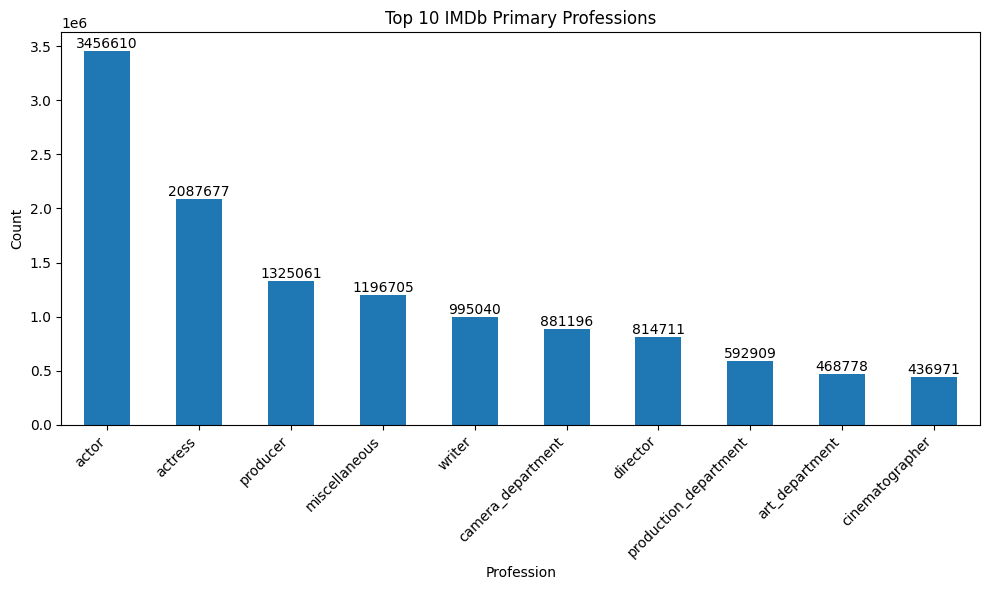

In [35]:
# Print a bar chart of the breakdown of the top 10 professions
names_df = imdb_dataframes["name_basics"]

# Clean data
names_df = names_df[names_df["primaryProfession"] != "\\N"]
names_df = names_df.dropna(subset=["primaryProfession"])

# Explode "primaryProfession" column
names_df["primaryProfession"] = names_df["primaryProfession"].str.split(",")
prof_rows = names_df.explode("primaryProfession")

# Isolate top-N professions
N=10
prof_counts = (
    prof_rows["primaryProfession"]
    .value_counts()
    .head(N)
)

# Plot results
plt.figure(figsize=(10, 6))
ax = prof_counts.plot(kind="bar")

plt.title("Top 10 IMDb Primary Professions")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(prof_counts):
    ax.text(i, value, str(value), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


# (E) Initial Insights and Direction

**Observations and Hypotheses:**
- *Regarding Primary Profession*
  - Observation: The most common IMDb "primary professions" appear to be those in an acting capacity.
  - Hypothesis: In predictive models of media success, features derived from the actors and actresses involved (e.g., their prior ratings, collaboration networks, or PageRank scores) will contribute more predictive power than features derived from other primary professions such as directors, writers, or producers.
- *Regarding Genres*
  - Observation: The most frequent genres between movies and TV diverge significantly after the first few common genres (Drama, Comedy)
  - Hypothesis: If genre frequency reflects audience demand (i.e. correlates to review prediction), then a predicitive model trained solely (or at least primarily) on movie data will predict poorly when fed TV series data (and vice versa)
- *Regarding Title Types*
  - Observation: TV episodes comprise over 75% of the titles represeneted in the dataset
  - Hypothesis: Because TV episodes make up the majority of titles in the IMDb dataset, applying a single global support threshold during association‑rule mining will bias the results toward episode‑driven patterns. Without stratifying or scaling support thresholds by title type, frequent‑itemset mining will either dilute meaningful episode‑level rules or suppress potentially informative movie‑level rules.
  
**Potential Research Questions:**
- *(Causal Inference)* Do directors who have experience working with successful directors go on to become directors themself?
- *(Time Series/Frequent Itemset)* How have genre preferences evolved over time? Do movies and shows categorized under multiple genres tend to perform better than those with only a single genere classification?
- *(Predictive Modeling/Frequent Itemset)* Can we predict a movie or TV serie's rating based on the cast and crew?

#(F) GitHub Portfolio Building

Link to GitHub repository: https://github.com/pmarshall21/CSCE_676

# Collaboration Declaration
On my honor, I declare the following resources:
1. Collaborators: N/A

2. Web Sources:
- Spotify Tracks Dataset: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data
- Open Data Commons Open Database License (ODbL) v1.0: https://opendatacommons.org/licenses/odbl/1-0/
- IMDb Non-Commercial Datasets: https://developer.imdb.com/non-commercial-datasets/
- FEC Datasets: https://www.fec.gov/data/browse-data/?tab=bulk-data

3. AI Tools:
- Microsoft Copilot: Queried how to perform standard dataset analysis (code created for creating data quality report) as well as assistance with writing code for calculating various metrics in Part (D).
- Gemini: Proposed solutions to issues in original implementation of `data_quality_report`

4. Citations: N/A